In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

%matplotlib inline

In [16]:
# 1. Credenciales de la Base de Datos LOCAL
DB_USER = "postgres"
DB_PASS = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "myvolt_local"

# 2. Codificar la contraseña
DB_PASS_ENCODED = quote_plus(DB_PASS)

# 3. Crear la cadena de conexión
try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(connection_string)
    
    # 4. Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a PostgreSQL LOCAL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a la BD Local: {e}")
    print("Consejo: Verifica que tu contraseña sea correcta y que PostgreSQL esté corriendo en el puerto 5432.")

¡Conexión a PostgreSQL LOCAL exitosa!


In [17]:
# Opción: Traer datos de consumo
# NOTA: Busca el ciclo de "percolado" (consumo alto continuo) y "mantenimiento" (pulsos cortos).
query = """
SELECT time, power_w
FROM consumption_data
ORDER BY time DESC; 
"""

df = pd.read_sql_query(query, con=engine)
print(f"Se cargaron {len(df)} registros para la Cafetera.")
df.head()

Se cargaron 3000 registros para la Cafetera.


,time,power_w
0,2026-01-27 19:02:21.114373,1062.30
1,2026-01-27 19:01:21.114373,868.93
2,2026-01-27 19:00:21.114373,936.18
3,2026-01-27 18:59:21.114373,990.17
4,2026-01-27 18:58:21.114373,913.95


In [18]:
datos_para_modelo = df[['power_w']]
datos_para_modelo.head()

,power_w
0,1062.30
1,868.93
2,936.18
3,990.17
4,913.95


In [19]:
# Contamination 0.1
modelo_if = IsolationForest(contamination=0.1, random_state=42)
modelo_if.fit(datos_para_modelo)
print("¡Modelo de la CAFETERA entrenado exitosamente!")

¡Modelo de la CAFETERA entrenado exitosamente!


In [20]:
predicciones = modelo_if.predict(datos_para_modelo)
df['anomalia_predicha'] = predicciones
anomalias = df[df['anomalia_predicha'] == -1]
print(f"El modelo detectó {len(anomalias)} anomalías de un total de {len(df)} registros.")
print("\nEjemplos de potencias anómalas (W) encontradas:")
print(anomalias['power_w'].value_counts().head())

El modelo detectó 300 anomalías de un total de 3000 registros.

Ejemplos de potencias anómalas (W) encontradas:
power_w
0.00    16
0.09     8
0.05     7
0.03     7
2.98     7
Name: count, dtype: int64


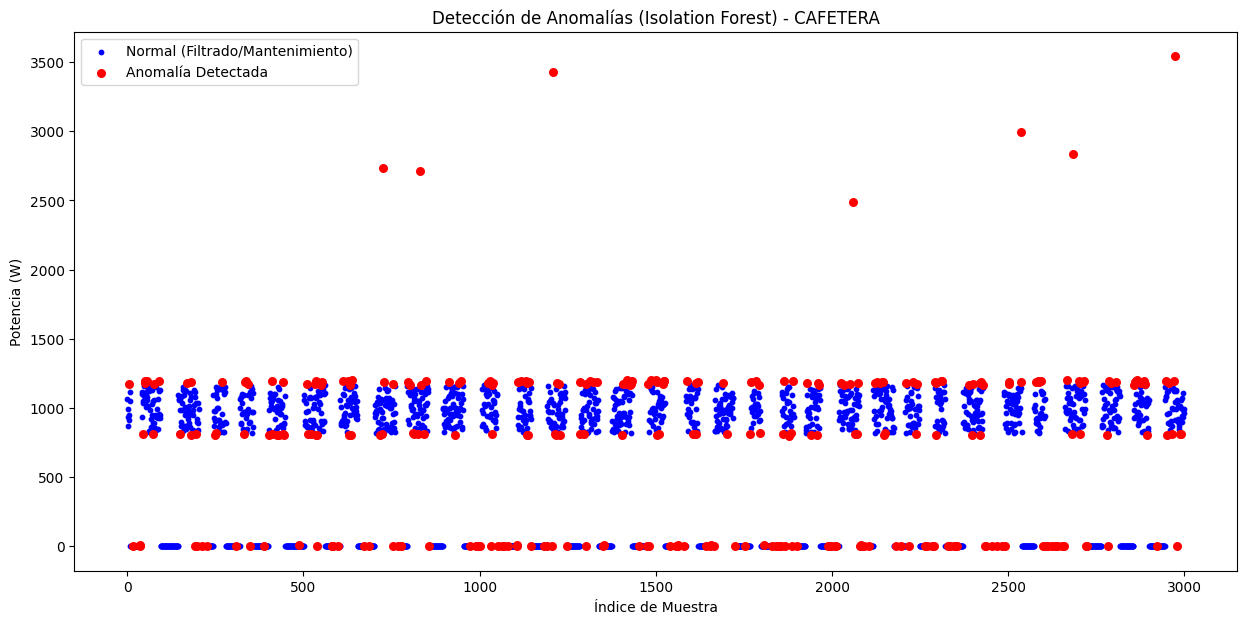

In [21]:
df_normal = df[df['anomalia_predicha'] == 1]
df_anomalo = df[df['anomalia_predicha'] == -1]

plt.figure(figsize=(15, 7))

# Pintamos los puntos normales en azul
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Filtrado/Mantenimiento)', s=10)

# Pintamos las anomalías en rojo
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía Detectada', s=30)

plt.title('Detección de Anomalías (Isolation Forest) - CAFETERA')

plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [22]:
ruta_modelo = '../models/models_v2/modelo_cafetera.pkl' 

joblib.dump(modelo_if, ruta_modelo)

print(f"¡ML de la Cafetera guardado exitosamente en {ruta_modelo}!")

¡ML de la Cafetera guardado exitosamente en ../models/models_v2/modelo_cafetera.pkl!
